<a href="https://colab.research.google.com/github/KashishK72/DSA-LAB/blob/main/Employee_Attrition_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd

In [6]:
import numpy as np

In [10]:
from google.colab import files
uploaded = files.upload()

Saving Employee_Attrition_SIP_Dataset.csv to Employee_Attrition_SIP_Dataset.csv


In [11]:
import pandas as pd
import numpy as np

df = pd.read_csv("Employee_Attrition_SIP_Dataset.csv")

df.head()

,EmployeeNumber,Age,Gender,MaritalStatus,Department,JobRole,BusinessTravel,DistanceFromHome,Education,EducationField,...,MonthlyIncome,NumCompaniesWorked,TotalWorkingYears,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,TrainingTimesLastYear,StockOptionLevel,PerformanceRating,Attrition
0,100001,29,Female,Married,Research & Development,Research Scientist,Travel_Rarely,8.0,4,Medical,...,5055.0,5,8,3,1,0.0,1,0,3,No
1,100002,46,Male,Single,Human Resources,Manager,Travel_Rarely,2.0,3,Life Sciences,...,2479.0,2,5,1,1,1.0,2,0,3,No
2,100003,19,Male,Married,Research & Development,Healthcare Representative,Travel_Rarely,18.0,5,Life Sciences,...,4267.0,2,11,2,1,0.0,3,1,3,Yes
3,100004,35,Male,Married,Research & Development,Human Resources,Travel_Rarely,5.0,1,Marketing,...,4289.0,2,25,16,5,4.0,4,1,3,No
4,100005,40,Male,Single,Sales,Healthcare Representative,Travel_Frequently,9.0,4,Life Sciences,...,6280.0,3,13,7,2,3.0,1,2,3,No


In [12]:
print("Dataset shape:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

Dataset shape: (1508, 27)

Column names:
['EmployeeNumber', 'Age', 'Gender', 'MaritalStatus', 'Department', 'JobRole', 'BusinessTravel', 'DistanceFromHome', 'Education', 'EducationField', 'JobLevel', 'JobInvolvement', 'JobSatisfaction', 'EnvironmentSatisfaction', 'RelationshipSatisfaction', 'WorkLifeBalance', 'OverTime', 'MonthlyIncome', 'NumCompaniesWorked', 'TotalWorkingYears', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'TrainingTimesLastYear', 'StockOptionLevel', 'PerformanceRating', 'Attrition']

Data types:
EmployeeNumber                int64
Age                           int64
Gender                       object
MaritalStatus                object
Department                   object
JobRole                      object
BusinessTravel               object
DistanceFromHome            float64
Education                     int64
EducationField               object
JobLevel                      int64
JobInvolvement                int64
JobSatisfaction           

In [13]:
print("Missing values in each column:")
print(df.isnull().sum())

print("\nNumber of duplicate rows:")
print(df.duplicated().sum())

Missing values in each column:
EmployeeNumber               0
Age                          0
Gender                       0
MaritalStatus                0
Department                   0
JobRole                      0
BusinessTravel               0
DistanceFromHome            15
Education                    0
EducationField               0
JobLevel                     0
JobInvolvement               0
JobSatisfaction             16
EnvironmentSatisfaction      0
RelationshipSatisfaction     0
WorkLifeBalance              0
OverTime                     0
MonthlyIncome               15
NumCompaniesWorked           0
TotalWorkingYears            0
YearsAtCompany               0
YearsInCurrentRole           0
YearsSinceLastPromotion     15
TrainingTimesLastYear        0
StockOptionLevel             0
PerformanceRating            0
Attrition                    0
dtype: int64

Number of duplicate rows:
8


In [14]:
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (1500, 27)


In [15]:
numeric_columns = df.select_dtypes(include=np.number).columns

for column in numeric_columns:
    df[column] = df[column].fillna(df[column].median())

In [16]:
print(df.isnull().sum().sum())

0


In [17]:
print("Final dataset shape:", df.shape)
print("Total missing values:", df.isnull().sum().sum())
print("Total duplicate rows:", df.duplicated().sum())

Final dataset shape: (1500, 27)
Total missing values: 0
Total duplicate rows: 0


In [18]:
print("Attrition counts:")
print(df["Attrition"].value_counts())

print("\nAttrition percentage:")
print(df["Attrition"].value_counts(normalize=True) * 100)

Attrition counts:
Attrition
No     1301
Yes     199
Name: count, dtype: int64

Attrition percentage:
Attrition
No     86.733333
Yes    13.266667
Name: proportion, dtype: float64


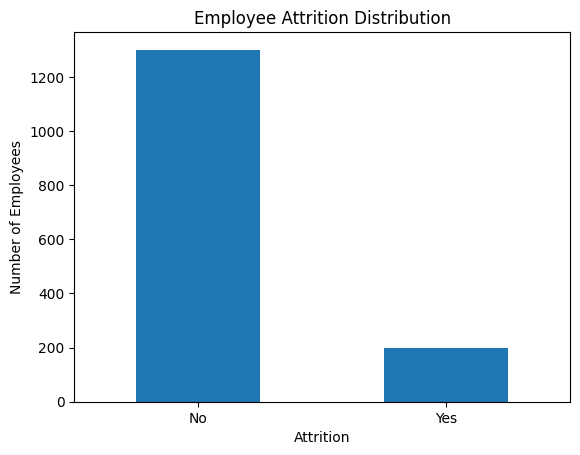

In [19]:
import matplotlib.pyplot as plt

df["Attrition"].value_counts().plot(kind="bar")

plt.title("Employee Attrition Distribution")
plt.xlabel("Attrition")
plt.ylabel("Number of Employees")
plt.xticks(rotation=0)
plt.show()

In [20]:
department_attrition = pd.crosstab(
    df["Department"],
    df["Attrition"],
    normalize="index"
) * 100

print(department_attrition)

Attrition                      No        Yes
Department                                  
Human Resources         84.313725  15.686275
Research & Development  87.173666  12.826334
Sales                   86.695279  13.304721


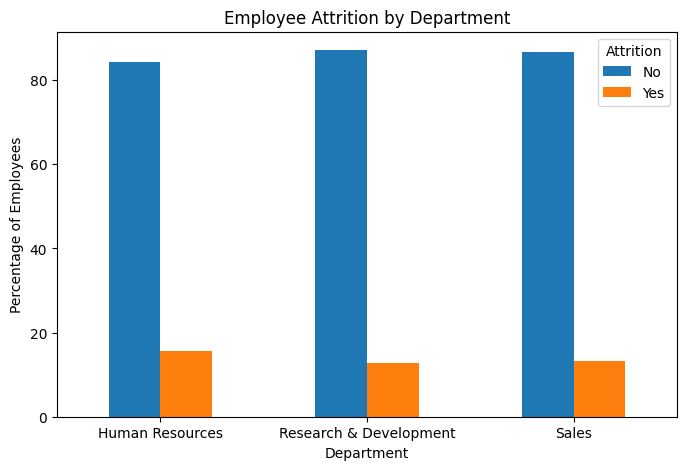

In [21]:
department_attrition.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Employee Attrition by Department")
plt.xlabel("Department")
plt.ylabel("Percentage of Employees")
plt.xticks(rotation=0)
plt.legend(title="Attrition")
plt.show()

In [22]:
jobrole_attrition = pd.crosstab(
    df["JobRole"],
    df["Attrition"],
    normalize="index"
) * 100

print(jobrole_attrition)

Attrition                         No        Yes
JobRole                                        
Healthcare Representative  85.310734  14.689266
Human Resources            85.542169  14.457831
Laboratory Technician      90.000000  10.000000
Manager                    83.815029  16.184971
Manufacturing Director     88.439306  11.560694
Research Director          86.982249  13.017751
Research Scientist         85.000000  15.000000
Sales Executive            88.679245  11.320755
Sales Representative       86.928105  13.071895


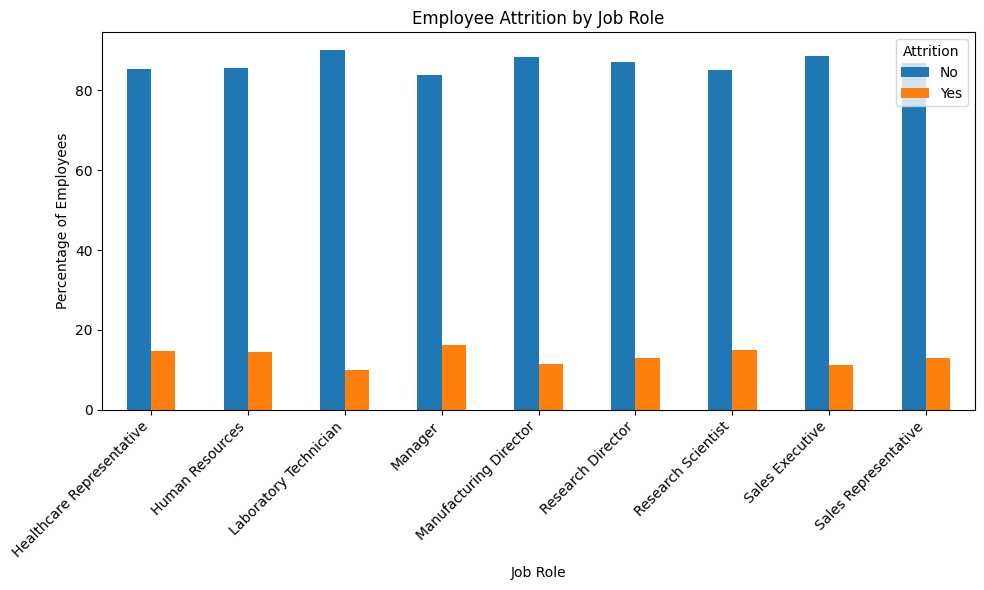

In [23]:
jobrole_attrition.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Employee Attrition by Job Role")
plt.xlabel("Job Role")
plt.ylabel("Percentage of Employees")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Attrition")
plt.tight_layout()
plt.show()

In [24]:
overtime_attrition = pd.crosstab(
    df["OverTime"],
    df["Attrition"],
    normalize="index"
) * 100

print(overtime_attrition)

Attrition         No        Yes
OverTime                       
No         89.478673  10.521327
Yes        80.224719  19.775281


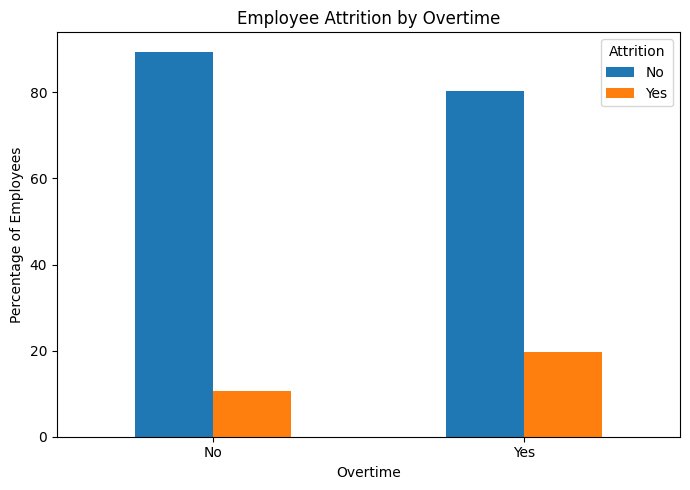

In [25]:
overtime_attrition.plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Employee Attrition by Overtime")
plt.xlabel("Overtime")
plt.ylabel("Percentage of Employees")
plt.xticks(rotation=0)
plt.legend(title="Attrition")
plt.tight_layout()
plt.show()

In [26]:
satisfaction_attrition = pd.crosstab(
    df["JobSatisfaction"],
    df["Attrition"],
    normalize="index"
) * 100

print(satisfaction_attrition)

Attrition               No        Yes
JobSatisfaction                      
1.0              83.726415  16.273585
2.0              88.268156  11.731844
3.0              87.719298  12.280702
4.0              87.765957  12.234043


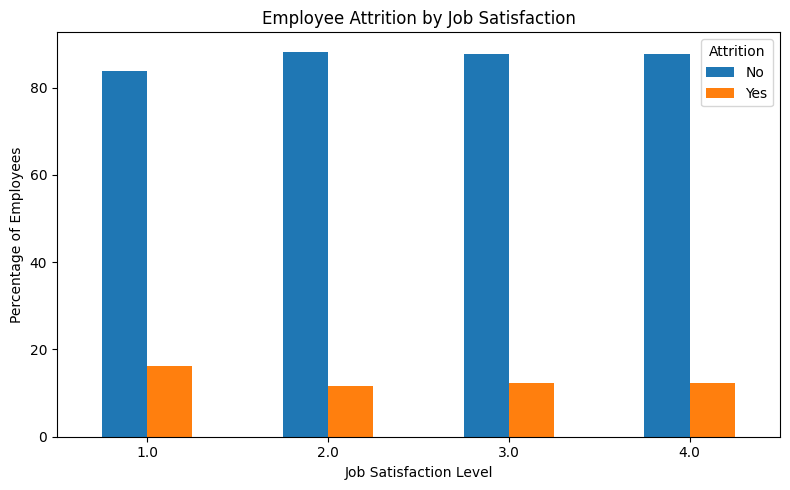

In [27]:
satisfaction_attrition.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Employee Attrition by Job Satisfaction")
plt.xlabel("Job Satisfaction Level")
plt.ylabel("Percentage of Employees")
plt.xticks(rotation=0)
plt.legend(title="Attrition")
plt.tight_layout()
plt.show()

<Figure size 800x500 with 0 Axes>

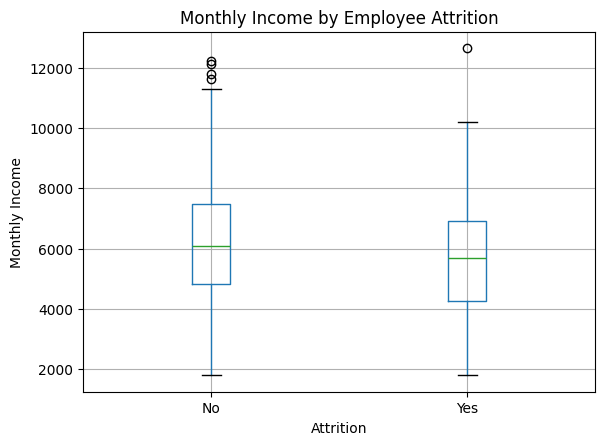

In [28]:
plt.figure(figsize=(8, 5))

df.boxplot(
    column="MonthlyIncome",
    by="Attrition"
)

plt.title("Monthly Income by Employee Attrition")
plt.suptitle("")
plt.xlabel("Attrition")
plt.ylabel("Monthly Income")
plt.show()

<Figure size 800x500 with 0 Axes>

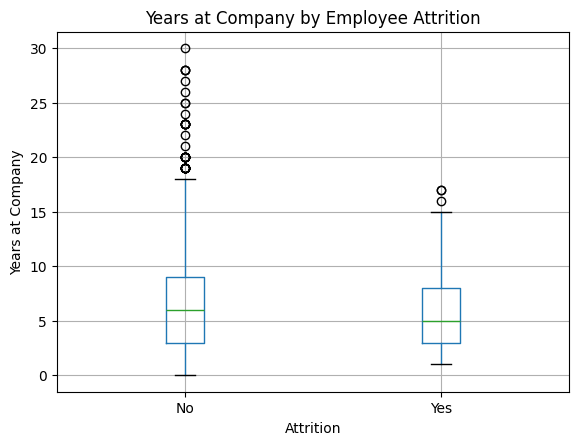

In [29]:
plt.figure(figsize=(8, 5))

df.boxplot(
    column="YearsAtCompany",
    by="Attrition"
)

plt.title("Years at Company by Employee Attrition")
plt.suptitle("")
plt.xlabel("Attrition")
plt.ylabel("Years at Company")
plt.show()

In [30]:
print(df.groupby("Attrition")["YearsAtCompany"].mean())

Attrition
No     7.036895
Yes    5.673367
Name: YearsAtCompany, dtype: float64


In [31]:
worklife_attrition = pd.crosstab(
    df["WorkLifeBalance"],
    df["Attrition"],
    normalize="index"
) * 100

print(worklife_attrition)

Attrition               No        Yes
WorkLifeBalance                      
1                86.397985  13.602015
2                87.463557  12.536443
3                87.297297  12.702703
4                85.897436  14.102564


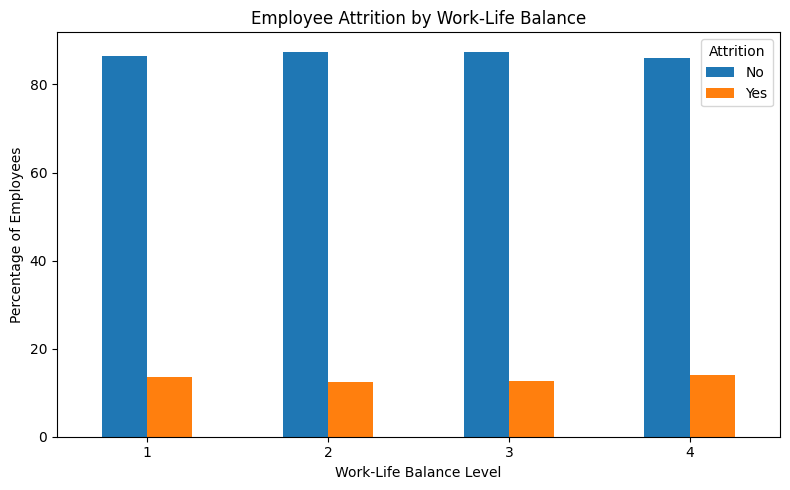

In [32]:
worklife_attrition.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Employee Attrition by Work-Life Balance")
plt.xlabel("Work-Life Balance Level")
plt.ylabel("Percentage of Employees")
plt.xticks(rotation=0)
plt.legend(title="Attrition")
plt.tight_layout()
plt.show()

<Figure size 800x500 with 0 Axes>

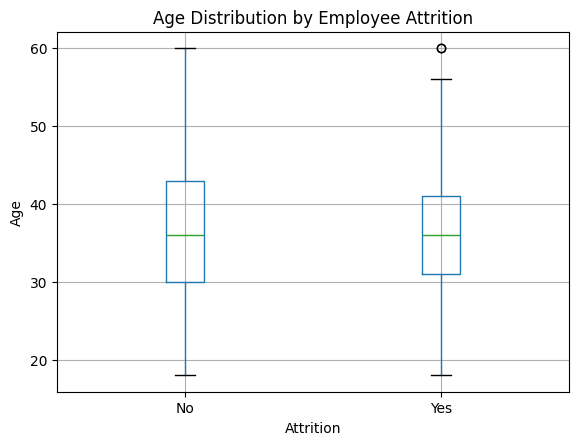

In [33]:
plt.figure(figsize=(8, 5))

df.boxplot(
    column="Age",
    by="Attrition"
)

plt.title("Age Distribution by Employee Attrition")
plt.suptitle("")
plt.xlabel("Attrition")
plt.ylabel("Age")
plt.show()

In [34]:
print(df.groupby("Attrition")["Age"].mean())

Attrition
No     36.329746
Yes    35.844221
Name: Age, dtype: float64


<Figure size 800x500 with 0 Axes>

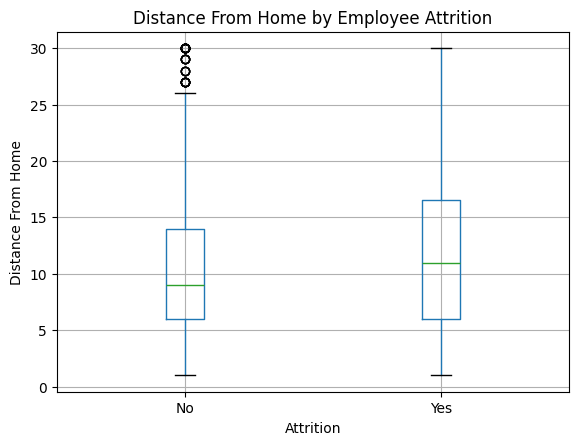

In [35]:
plt.figure(figsize=(8, 5))

df.boxplot(
    column="DistanceFromHome",
    by="Attrition"
)

plt.title("Distance From Home by Employee Attrition")
plt.suptitle("")
plt.xlabel("Attrition")
plt.ylabel("Distance From Home")
plt.show()

In [36]:
print(df.groupby("Attrition")["DistanceFromHome"].mean())

Attrition
No     10.498078
Yes    11.949749
Name: DistanceFromHome, dtype: float64


In [37]:
travel_attrition = pd.crosstab(
    df["BusinessTravel"],
    df["Attrition"],
    normalize="index"
) * 100

print(travel_attrition)

Attrition                 No        Yes
BusinessTravel                         
Non-Travel         84.444444  15.555556
Travel_Frequently  81.368821  18.631179
Travel_Rarely      88.457900  11.542100


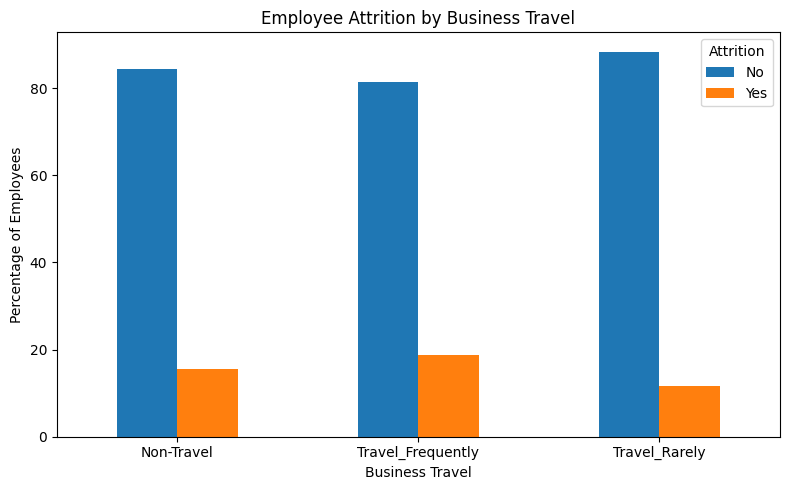

In [38]:
travel_attrition.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Employee Attrition by Business Travel")
plt.xlabel("Business Travel")
plt.ylabel("Percentage of Employees")
plt.xticks(rotation=0)
plt.legend(title="Attrition")
plt.tight_layout()
plt.show()

In [39]:
joblevel_attrition = pd.crosstab(
    df["JobLevel"],
    df["Attrition"],
    normalize="index"
) * 100

print(joblevel_attrition)

Attrition         No         Yes
JobLevel                        
1          83.622351   16.377649
2          88.159437   11.840563
3          90.551181    9.448819
4           0.000000  100.000000


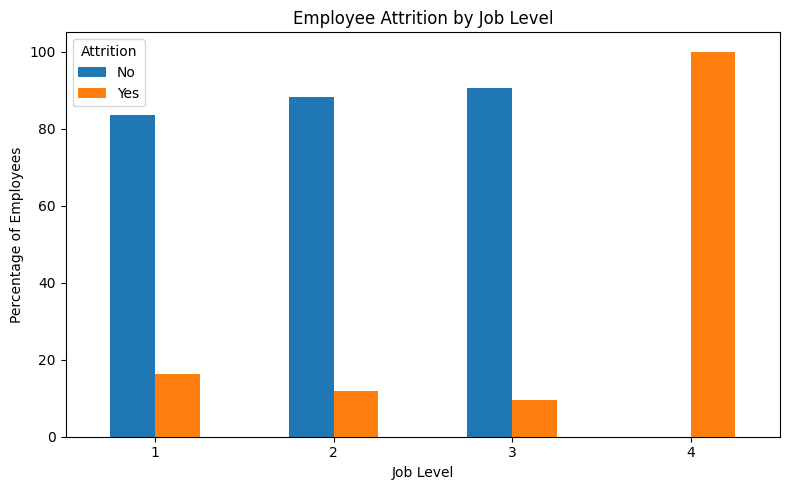

In [40]:
joblevel_attrition.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Employee Attrition by Job Level")
plt.xlabel("Job Level")
plt.ylabel("Percentage of Employees")
plt.xticks(rotation=0)
plt.legend(title="Attrition")
plt.tight_layout()
plt.show()

In [41]:
promotion_attrition = pd.crosstab(
    df["YearsSinceLastPromotion"],
    df["Attrition"],
    normalize="index"
) * 100

print(promotion_attrition)

Attrition                        No        Yes
YearsSinceLastPromotion                       
0.0                       83.928571  16.071429
1.0                       87.195122  12.804878
2.0                       86.404834  13.595166
3.0                       86.602871  13.397129
4.0                       89.705882  10.294118
5.0                       91.666667   8.333333
6.0                       93.548387   6.451613
7.0                      100.000000   0.000000
8.0                      100.000000   0.000000
9.0                      100.000000   0.000000


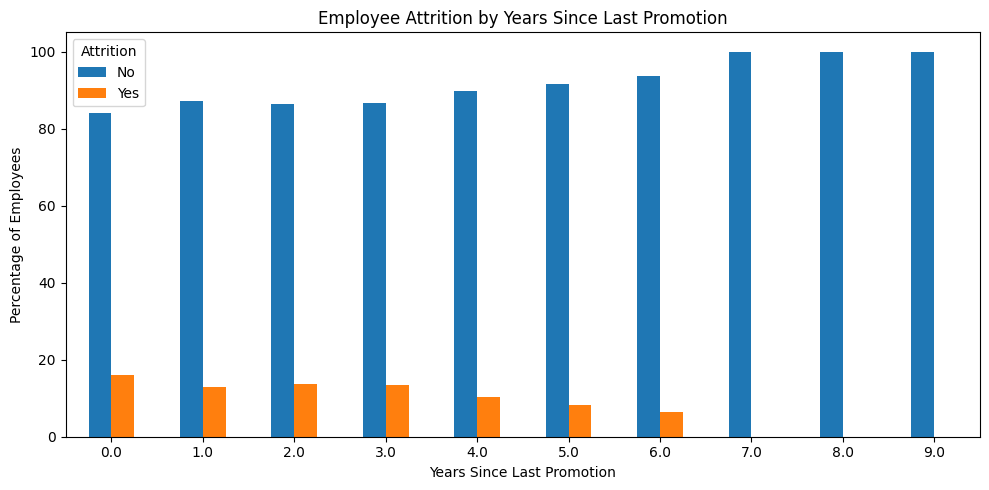

In [42]:
promotion_attrition.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Employee Attrition by Years Since Last Promotion")
plt.xlabel("Years Since Last Promotion")
plt.ylabel("Percentage of Employees")
plt.xticks(rotation=0)
plt.legend(title="Attrition")
plt.tight_layout()
plt.show()

In [43]:
print("===== KEY ATTRITION RATES =====")

print("\n1. Overall Attrition:")
print(df["Attrition"].value_counts(normalize=True).mul(100).round(2))

print("\n2. Attrition by Overtime:")
print(pd.crosstab(
    df["OverTime"],
    df["Attrition"],
    normalize="index"
).mul(100).round(2))

print("\n3. Attrition by Department:")
print(pd.crosstab(
    df["Department"],
    df["Attrition"],
    normalize="index"
).mul(100).round(2))

print("\n4. Attrition by Job Role:")
print(pd.crosstab(
    df["JobRole"],
    df["Attrition"],
    normalize="index"
).mul(100).round(2))

print("\n5. Attrition by Job Satisfaction:")
print(pd.crosstab(
    df["JobSatisfaction"],
    df["Attrition"],
    normalize="index"
).mul(100).round(2))

print("\n6. Average Years at Company:")
print(df.groupby("Attrition")["YearsAtCompany"].mean().round(2))

print("\n7. Average Monthly Income:")
print(df.groupby("Attrition")["MonthlyIncome"].mean().round(2))

print("\n8. Average Age:")
print(df.groupby("Attrition")["Age"].mean().round(2))

===== KEY ATTRITION RATES =====

1. Overall Attrition:
Attrition
No     86.73
Yes    13.27
Name: proportion, dtype: float64

2. Attrition by Overtime:
Attrition     No    Yes
OverTime               
No         89.48  10.52
Yes        80.22  19.78

3. Attrition by Department:
Attrition                  No    Yes
Department                          
Human Resources         84.31  15.69
Research & Development  87.17  12.83
Sales                   86.70  13.30

4. Attrition by Job Role:
Attrition                     No    Yes
JobRole                                
Healthcare Representative  85.31  14.69
Human Resources            85.54  14.46
Laboratory Technician      90.00  10.00
Manager                    83.82  16.18
Manufacturing Director     88.44  11.56
Research Director          86.98  13.02
Research Scientist         85.00  15.00
Sales Executive            88.68  11.32
Sales Representative       86.93  13.07

5. Attrition by Job Satisfaction:
Attrition           No    Yes
JobSati

In [44]:
from scipy.stats import chi2_contingency

contingency_table = pd.crosstab(
    df["OverTime"],
    df["Attrition"]
)

print("Contingency Table:")
print(contingency_table)

chi2, p_value, degrees_of_freedom, expected = chi2_contingency(
    contingency_table
)

print("\nChi-square statistic:", chi2)
print("p-value:", p_value)
print("Degrees of freedom:", degrees_of_freedom)

Contingency Table:
Attrition   No  Yes
OverTime           
No         944  111
Yes        357   88

Chi-square statistic: 22.495852265475015
p-value: 2.1059783758577897e-06
Degrees of freedom: 1


In [45]:
if p_value < 0.05:
    print("Result: There is a statistically significant association between OverTime and Attrition.")
else:
    print("Result: There is no statistically significant association between OverTime and Attrition.")

Result: There is a statistically significant association between OverTime and Attrition.


In [46]:
df["Attrition"] = df["Attrition"].map({
    "Yes": 1,
    "No": 0
})

print(df["Attrition"].value_counts())

Attrition
0    1301
1     199
Name: count, dtype: int64


In [47]:
df[["Attrition"]].head()

,Attrition
0,0
1,0
2,1
3,0
4,0


In [48]:
features = [
    "Age",
    "JobLevel",
    "JobSatisfaction",
    "EnvironmentSatisfaction",
    "WorkLifeBalance",
    "OverTime",
    "MonthlyIncome",
    "YearsAtCompany",
    "YearsInCurrentRole",
    "YearsSinceLastPromotion",
    "DistanceFromHome",
    "NumCompaniesWorked",
    "TrainingTimesLastYear",
    "StockOptionLevel"
]

X = df[features]
y = df["Attrition"]

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

Features:
['Age', 'JobLevel', 'JobSatisfaction', 'EnvironmentSatisfaction', 'WorkLifeBalance', 'OverTime', 'MonthlyIncome', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'DistanceFromHome', 'NumCompaniesWorked', 'TrainingTimesLastYear', 'StockOptionLevel']

Target:
Attrition


In [49]:
X["OverTime"] = X["OverTime"].map({
    "Yes": 1,
    "No": 0
})

print(X.head())
print("\nData types:")
print(X.dtypes)

   Age  JobLevel  JobSatisfaction  EnvironmentSatisfaction  WorkLifeBalance  \
0   29         1              4.0                        2                4   
1   46         1              3.0                        2                1   
2   19         1              3.0                        2                4   
3   35         1              3.0                        4                3   
4   40         2              1.0                        1                4   

   OverTime  MonthlyIncome  YearsAtCompany  YearsInCurrentRole  \
0         0         5055.0               3                   1   
1         0         2479.0               1                   1   
2         1         4267.0               2                   1   
3         0         4289.0              16                   5   
4         0         6280.0               7                   2   

   YearsSinceLastPromotion  DistanceFromHome  NumCompaniesWorked  \
0                      0.0               8.0                

/tmp/ipykernel_5152/81076754.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["OverTime"] = X["OverTime"].map({


In [50]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (1200, 14)
Testing data: (300, 14)


In [51]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [52]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter=2000)

model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [53]:
y_pred = model.predict(X_test_scaled)

print("First 20 predictions:")
print(y_pred[:20])

First 20 predictions:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [54]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", round(accuracy * 100, 2), "%")

Model Accuracy: 86.67 %


In [55]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print("Classification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Stayed", "Left"]
))

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.87      1.00      0.93       260
        Left       0.00      0.00      0.00        40

    accuracy                           0.87       300
   macro avg       0.43      0.50      0.46       300
weighted avg       0.75      0.87      0.80       300



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [56]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print("Classification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Stayed", "Left"],
    zero_division=0
))

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.87      1.00      0.93       260
        Left       0.00      0.00      0.00        40

    accuracy                           0.87       300
   macro avg       0.43      0.50      0.46       300
weighted avg       0.75      0.87      0.80       300



In [57]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced"
)

model.fit(X_train_scaled, y_train)

print("Balanced Logistic Regression model trained successfully.")

Balanced Logistic Regression model trained successfully.


In [58]:
y_pred_balanced = model.predict(X_test_scaled)

print("First 20 predictions:")
print(y_pred_balanced[:20])

First 20 predictions:
[1 1 0 1 1 0 1 1 0 1 0 1 1 0 1 0 1 0 0 0]


In [59]:
from sklearn.metrics import accuracy_score

balanced_accuracy = accuracy_score(y_test, y_pred_balanced)

print("Balanced Model Accuracy:", round(balanced_accuracy * 100, 2), "%")

Balanced Model Accuracy: 59.33 %


In [60]:
from sklearn.metrics import classification_report

print("Balanced Model Classification Report:")

print(classification_report(
    y_test,
    y_pred_balanced,
    target_names=["Stayed", "Left"],
    zero_division=0
))

Balanced Model Classification Report:
              precision    recall  f1-score   support

      Stayed       0.90      0.60      0.72       260
        Left       0.17      0.55      0.27        40

    accuracy                           0.59       300
   macro avg       0.54      0.57      0.49       300
weighted avg       0.80      0.59      0.66       300



Confusion Matrix:
[[156 104]
 [ 18  22]]


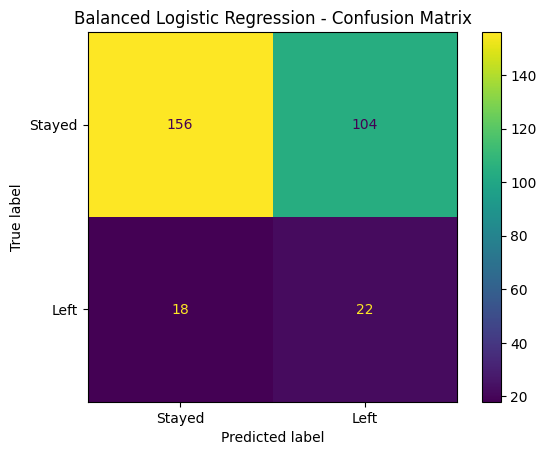

In [61]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_balanced)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Stayed", "Left"]
)

disp.plot()
plt.title("Balanced Logistic Regression - Confusion Matrix")
plt.show()

In [62]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

coefficients["Absolute_Importance"] = coefficients["Coefficient"].abs()

coefficients = coefficients.sort_values(
    "Absolute_Importance",
    ascending=False
)

print(coefficients[["Feature", "Coefficient"]])

                    Feature  Coefficient
6             MonthlyIncome    -0.376399
5                  OverTime     0.301935
10         DistanceFromHome     0.275311
2           JobSatisfaction    -0.236407
8        YearsInCurrentRole    -0.189386
13         StockOptionLevel    -0.150760
11       NumCompaniesWorked     0.149466
1                  JobLevel     0.148411
7            YearsAtCompany    -0.090737
12    TrainingTimesLastYear     0.087166
9   YearsSinceLastPromotion    -0.075340
0                       Age     0.032225
4           WorkLifeBalance     0.028540
3   EnvironmentSatisfaction     0.007006


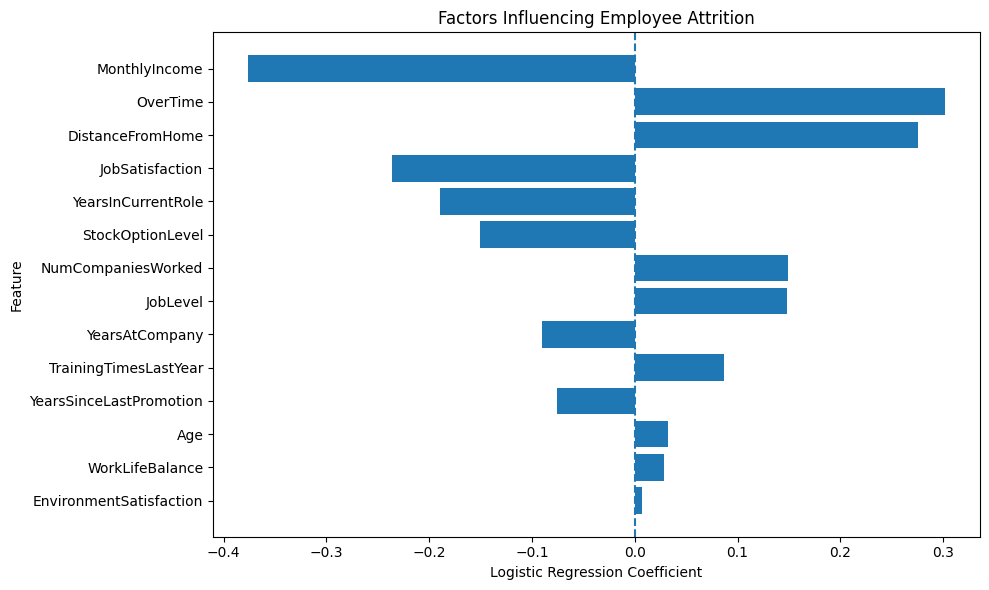

In [63]:
plt.figure(figsize=(10, 6))

plt.barh(
    coefficients["Feature"],
    coefficients["Coefficient"]
)

plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")
plt.title("Factors Influencing Employee Attrition")
plt.axvline(x=0, linestyle="--")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [64]:
tableau_df = df.copy()

# Convert Attrition back to Yes/No for easier interpretation in Tableau
tableau_df["Attrition"] = tableau_df["Attrition"].map({
    1: "Yes",
    0: "No"
})

# Save the cleaned dataset
tableau_df.to_csv(
    "Employee_Attrition_Cleaned.csv",
    index=False
)

print("Cleaned dataset created successfully.")
print("Rows:", tableau_df.shape[0])
print("Columns:", tableau_df.shape[1])

Cleaned dataset created successfully.
Rows: 1500
Columns: 27


In [65]:
import os

print(os.listdir())

['.config', 'Employee_Attrition_SIP_Dataset.csv', 'Employee_Attrition_SIP_Dataset (1) (1).csv', 'Employee_Attrition_Cleaned.csv', 'Employee_Attrition_SIP_Dataset (1).csv', 'sample_data']
